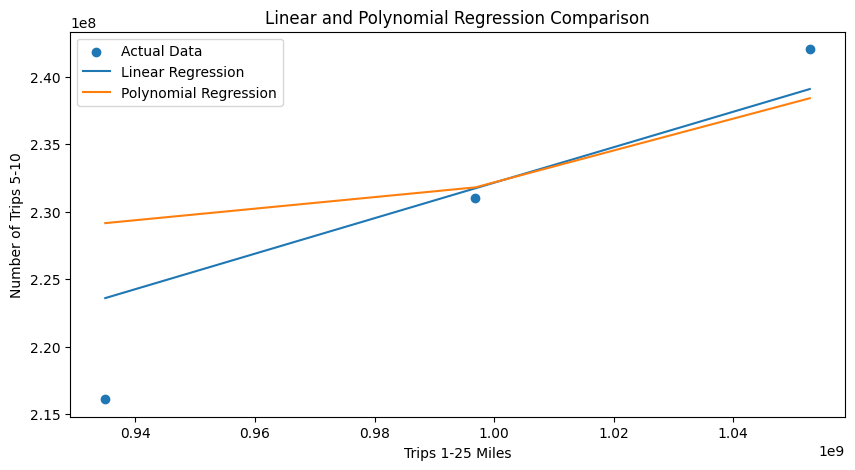

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# load datasets
td = pd.read_csv("Trips_by_Distance.csv", parse_dates=["Date"])
tf = pd.read_csv("Trips_Full Data.csv", parse_dates=["Date"])

# keep only national level data
td = td[td["Level"] == "National"]
tf = tf[tf["Level"] == "National"]

# merge required columns
model_data = pd.merge(
    tf[["Date", "Trips 1-25 Miles"]],
    td[["Date", "Number of Trips 5-10"]],
    on="Date",
    how="inner"
).dropna()

x = model_data[["Trips 1-25 Miles"]]
y = model_data["Number of Trips 5-10"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

# linear regression
linear_model = LinearRegression()
linear_model.fit(x_train, y_train)
y_pred_linear = linear_model.predict(x_test)

# polynomial regression
poly = PolynomialFeatures(degree=2)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

poly_model = LinearRegression()
poly_model.fit(x_train_poly, y_train)
y_pred_poly = poly_model.predict(x_test_poly)

# sort for smooth line
x_test_sorted = x_test.sort_values(by="Trips 1-25 Miles")
y_linear_sorted = linear_model.predict(x_test_sorted)
x_test_poly_sorted = poly.transform(x_test_sorted)
y_poly_sorted = poly_model.predict(x_test_poly_sorted)

# plot
plt.figure(figsize=(10, 5))
plt.scatter(x_test, y_test, label="Actual Data")
plt.plot(x_test_sorted, y_linear_sorted, label="Linear Regression")
plt.plot(x_test_sorted, y_poly_sorted, label="Polynomial Regression")
plt.xlabel("Trips 1-25 Miles")
plt.ylabel("Number of Trips 5-10")
plt.title("Linear and Polynomial Regression Comparison")
plt.legend()
plt.show()